# Importing Recinos

# Set up the environment

In [160]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from unidecode import unidecode

In [161]:
import spacy

In [162]:
spacy.__version__

'3.8.14'

In [163]:
nlp = spacy.load('es_core_news_lg')

# Import the text ($F0$)

In [164]:
recinos_src = f"recinos.txt"

In [165]:
recinos = pd.DataFrame([line.strip() for line in open(recinos_src, "r").readlines()], 
                       columns=['line_str'])
recinos.index.name = "line_num"

In [166]:
recinos.head()

,line_str
line_num,
0,# POPOL VUH: Las antiguas historias de Quiché
1,"# Traducción, introducción y notas de Adrían R..."
2,
3,PREÁMBULO
4,


# Prepare the text

## Clip the cruft 

Here we exclude the footnotes.

In [167]:
recinos

,line_str
line_num,
0,# POPOL VUH: Las antiguas historias de Quiché
1,"# Traducción, introducción y notas de Adrían R..."
2,
3,PREÁMBULO
4,
...,...
3471,"mahabi chi ilbal re Popo Vuh, y la del capítul..."
3472,"ilbal re, qovuh,Popol Vuh u bi cumal. El autor..."
3473,ha tenido que escribirla porque ya no existe e...


In [168]:
a = 3 # By visual inspection
b = 2807 # By visual inspection

In [169]:
recinos = recinos.iloc[a:b].copy().reset_index(drop=True)

In [170]:
recinos

,line_str
0,PREÁMBULO
1,
2,CAPÍTULO PRIMERO
3,
4,Este es el principio de las antiguas historias...
...,...
2799,"Chocoh, que representaba cada uno a su familia."
2800,"Y ésta fue la existencia de los quichés, porqu..."
2801,"tenían antiguamente los reyes,51 pues ha desap..."
2802,"Así, pues, se han acabado todos los del Quiché..."


# Remove arabic numbers

In [171]:
recinos.line_str = recinos.line_str.str.replace(r"\d+", "", regex=True)

## Chunk by Part

In [172]:
recinos['parte'] = recinos.loc[recinos.line_str.str.contains(r"(?:PREÁMBULO|PARTE)", regex=True), 'line_str']
recinos['parte'] = recinos.parte.ffill()

In [173]:
recinos

,line_str,parte
0,PREÁMBULO,PREÁMBULO
1,,PREÁMBULO
2,CAPÍTULO PRIMERO,PREÁMBULO
3,,PREÁMBULO
4,Este es el principio de las antiguas historias...,PREÁMBULO
...,...,...
2799,"Chocoh, que representaba cada uno a su familia.",CUARTA PARTE
2800,"Y ésta fue la existencia de los quichés, porqu...",CUARTA PARTE
2801,"tenían antiguamente los reyes, pues ha desapar...",CUARTA PARTE
2802,"Así, pues, se han acabado todos los del Quiché...",CUARTA PARTE


## Chunk by Chapter

In [174]:
recinos['capit'] = recinos.loc[recinos.line_str.str.contains(r"(?:CAPÍTULO|CAPITULO)", regex=True)].line_str
recinos['capit'] = recinos.capit.ffill()

In [175]:
recinos = recinos.dropna(subset=['parte'])

In [176]:
recinos

,line_str,parte,capit
0,PREÁMBULO,PREÁMBULO,NaN
1,,PREÁMBULO,NaN
2,CAPÍTULO PRIMERO,PREÁMBULO,CAPÍTULO PRIMERO
3,,PREÁMBULO,CAPÍTULO PRIMERO
4,Este es el principio de las antiguas historias...,PREÁMBULO,CAPÍTULO PRIMERO
...,...,...,...
2799,"Chocoh, que representaba cada uno a su familia.",CUARTA PARTE,CAPÍTULO XII
2800,"Y ésta fue la existencia de los quichés, porqu...",CUARTA PARTE,CAPÍTULO XII
2801,"tenían antiguamente los reyes, pues ha desapar...",CUARTA PARTE,CAPÍTULO XII
2802,"Así, pues, se han acabado todos los del Quiché...",CUARTA PARTE,CAPÍTULO XII


## Remove extra lines

In [177]:
recinos = recinos[~recinos.capit.isna()]
recinos = recinos.loc[~(recinos.line_str == recinos.parte)]
recinos = recinos.loc[~(recinos.line_str == recinos.capit)]
recinos = recinos.loc[~(recinos.line_str == '')]

In [178]:
recinos

,line_str,parte,capit
4,Este es el principio de las antiguas historias...,PREÁMBULO,CAPÍTULO PRIMERO
5,"y comenzaremos las antiguas historias, el pri...",PREÁMBULO,CAPÍTULO PRIMERO
6,"de Quiché, por las tribus de la nación quiché.",PREÁMBULO,CAPÍTULO PRIMERO
7,"Y aquí traeremos la manifestación, la publicac...",PREÁMBULO,CAPÍTULO PRIMERO
8,"por Tzacol, Bitol, Alom, Qaholom, que se llama...",PREÁMBULO,CAPÍTULO PRIMERO
...,...,...,...
2798,"y el Nim-Chocoh-Ahau de los Ahau-Quiché, que e...",CUARTA PARTE,CAPÍTULO XII
2799,"Chocoh, que representaba cada uno a su familia.",CUARTA PARTE,CAPÍTULO XII
2800,"Y ésta fue la existencia de los quichés, porqu...",CUARTA PARTE,CAPÍTULO XII
2801,"tenían antiguamente los reyes, pues ha desapar...",CUARTA PARTE,CAPÍTULO XII


## Convert Division Names to Integers

Handle Parts

In [179]:
# recinos.parte.value_counts()

In [180]:
part_seq = {
    'SEGUNDA PARTE': 2,
    'CUARTA PARTE': 4,
    'PRIMERA PARTE': 1,
    'TERCERA PARTE': 3,
    'PREÁMBULO': 0
}

In [181]:
recinos['parte'] = recinos['parte'].apply(lambda x: part_seq[x])

In [182]:
recinos

,line_str,parte,capit
4,Este es el principio de las antiguas historias...,0,CAPÍTULO PRIMERO
5,"y comenzaremos las antiguas historias, el pri...",0,CAPÍTULO PRIMERO
6,"de Quiché, por las tribus de la nación quiché.",0,CAPÍTULO PRIMERO
7,"Y aquí traeremos la manifestación, la publicac...",0,CAPÍTULO PRIMERO
8,"por Tzacol, Bitol, Alom, Qaholom, que se llama...",0,CAPÍTULO PRIMERO
...,...,...,...
2798,"y el Nim-Chocoh-Ahau de los Ahau-Quiché, que e...",4,CAPÍTULO XII
2799,"Chocoh, que representaba cada uno a su familia.",4,CAPÍTULO XII
2800,"Y ésta fue la existencia de los quichés, porqu...",4,CAPÍTULO XII
2801,"tenían antiguamente los reyes, pues ha desapar...",4,CAPÍTULO XII


Handle Chapters

In [183]:
recinos.loc[recinos.capit.str.match(r"CAP[IÍ]TULO"), 'capit'] = recinos.capit\
    .str.replace(r"CAP[IÍ]TULO ", "", regex=True)

In [184]:
recinos

,line_str,parte,capit
4,Este es el principio de las antiguas historias...,0,PRIMERO
5,"y comenzaremos las antiguas historias, el pri...",0,PRIMERO
6,"de Quiché, por las tribus de la nación quiché.",0,PRIMERO
7,"Y aquí traeremos la manifestación, la publicac...",0,PRIMERO
8,"por Tzacol, Bitol, Alom, Qaholom, que se llama...",0,PRIMERO
...,...,...,...
2798,"y el Nim-Chocoh-Ahau de los Ahau-Quiché, que e...",4,XII
2799,"Chocoh, que representaba cada uno a su familia.",4,XII
2800,"Y ésta fue la existencia de los quichés, porqu...",4,XII
2801,"tenían antiguamente los reyes, pues ha desapar...",4,XII


In [185]:
# recinos.capit.value_counts()

In [186]:
chap_seq = {
    'PRIMERO': 1,
    'I': 1,
    'II': 2,
    'III': 3,
    'IV': 4,
    'V': 5,
    'VI': 6,
    'VII': 7,
    'VIII': 8,
    'IX': 9,
    'X': 10,
    'XI': 11,
    'XII': 12,
    'XIII': 13,
    'XIV': 14
}

In [187]:
recinos['capit'] = recinos['capit'].apply(lambda x: chap_seq[x])

In [188]:
recinos

,line_str,parte,capit
4,Este es el principio de las antiguas historias...,0,1
5,"y comenzaremos las antiguas historias, el pri...",0,1
6,"de Quiché, por las tribus de la nación quiché.",0,1
7,"Y aquí traeremos la manifestación, la publicac...",0,1
8,"por Tzacol, Bitol, Alom, Qaholom, que se llama...",0,1
...,...,...,...
2798,"y el Nim-Chocoh-Ahau de los Ahau-Quiché, que e...",4,12
2799,"Chocoh, que representaba cada uno a su familia.",4,12
2800,"Y ésta fue la existencia de los quichés, porqu...",4,12
2801,"tenían antiguamente los reyes, pues ha desapar...",4,12


## Convert to CHAP table ($F1$)

In [189]:
OHCO = ['parte','capit']
CHAP = recinos.groupby(OHCO).line_str.apply(lambda x: ' '.join(x)).to_frame('doc_str').reindex()
CHAP['n_chars'] = CHAP.doc_str.str.len()
CHAP['n_words'] = CHAP.doc_str.str.split().apply(len)

In [190]:
len(CHAP)

46

In [191]:
# CHAP.n_words.cumsum().plot.bar();

Here's a quick view of the distribution of text by part.

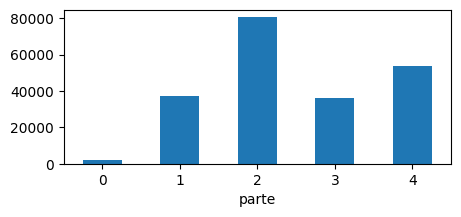

In [192]:
CHAP.groupby(OHCO[:1]).n_chars.sum().plot.bar(rot=0, figsize=(5,2));

In [193]:
# CHAP

# CHAP to DOC and DOCMAP

In [194]:
doc_idx = ['parte', 'capit']
DOCRAW = CHAP.reset_index().copy()
DOCRAW.index.name = 'doc_id'
DOC = DOCRAW[['doc_str']]
DOCMAP = DOCRAW[doc_idx]
DOCMAP

,parte,capit
doc_id,,
0,0,1
1,1,1
2,1,2
3,1,3
4,1,4
5,1,5
6,1,6
7,1,7
8,1,8


# Parse the text

## Convert chapters to SpaCy `Doc` objects

We first apply the model to the texts segmented by chapter.

We use SpaCy, which like many NLP tools, expects data in $F1$ format.

This produces a dataframe of SpaCy Doc objects.

In [195]:
SPACY = CHAP.doc_str.apply(nlp)

## Create TOKEN with SpaCy ($F2$)

Next, we extract sentences and tokens from the Doc objects and put them into F2 structure.

In [196]:
# SPACY.apply(lambda x: [sent for sent in x.sents]).apply(pd.Series).stack().dropna()

In [197]:
TOKEN = SPACY\
    .apply(lambda x: [sent for sent in x.sents]).apply(pd.Series).stack().dropna()\
    .apply(lambda x: [[token.text, token.lemma_, token.pos_, token.dep_] for token in x]).apply(pd.Series).stack()\
    .apply(pd.Series)\
    .dropna()
TOKEN.index.names = OHCO + ['sent', 'token']
TOKEN.columns = ['token_str', 'token_lemma', 'token_pos', 'token_dep']
TOKEN['term_str'] = TOKEN.token_str.str.replace(r"\W+", "", regex=True).str.lower().apply(unidecode)

# Investiage parts of speech

In [198]:
POS = TOKEN.token_pos.value_counts().to_frame('n')

In [199]:
POS

,n
token_pos,
PUNCT,6716
NOUN,6099
DET,5302
VERB,4990
ADP,4693
PRON,3468
PROPN,2454
CCONJ,2294
ADV,2207


In [200]:
TOKEN.loc[TOKEN.term_str == 'tohil']

token_str token_lemma token_pos token_dep term_str
parte capit sent token                                                   
3     4     13   6         Tohil       Tohil     PROPN      ROOT    tohil
            17   2         Tohil       Tohil     PROPN     nsubj    tohil
            19   0         Tohil       Tohil     PROPN     nsubj    tohil
            20   22        Tohil       Tohil     PROPN     nsubj    tohil
                 27        Tohil       Tohil     PROPN     appos    tohil
...                          ...         ...       ...       ...      ...
4     3     32   40        Tohil       Tohil     PROPN       obj    tohil
            33   9         Tohil       Tohil     PROPN       obj    tohil
      11    2    4         Tohil       Tohil     PROPN      flat    tohil
            15   13        Tohil       Tohil     PROPN       obl    tohil
            31   44        Tohil       Tohil     PROPN     nsubj    tohil

[75 rows x 5 columns]

In [201]:
PROPN = TOKEN.loc[TOKEN.token_pos == 'PROPN'].term_str.value_counts().to_frame('n')

In [202]:
PROPN

,n
term_str,
seores,126
xibalb,105
hunahp,88
tohil,75
ixbalanqu,69
...,...
coyobacoh,1
lolmetahau,1
renanse,1


# Extract other things

## Extract SpaCy's `Vocab` object

In [203]:
VOCABX = pd.DataFrame([[w.text, w.norm_, w.is_stop, w.vector_norm] for w in nlp.vocab if w.is_alpha], columns=['token_str', 'term_str', 'stop', 'vnorm'])
VOCABX.sort_values('vnorm', ascending=False)
VOCABX = VOCABX.set_index('term_str')

SpaCy also includes vectors (embeddings) for each word.

## Extract vectors

In [204]:
VOCAB_VEC = pd.DataFrame(
    [[unidecode(w.text.lower()), w.vector] for w in nlp.vocab if w.is_alpha], 
    columns=['term_str', 'vnorm'])\
    .set_index('term_str')\
    .vnorm.apply(pd.Series)

In [205]:
VOCAB_VEC = VOCAB_VEC.drop_duplicates()

In [206]:
VOCAB_VEC.loc[VOCAB_VEC.index.duplicated()]

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
term_str,,,,,,,,,,,,,,,,,,,,,
buhos,-0.68233,-0.79662,-0.82534,1.054500,1.056200,0.41921,-1.41530,-0.25189,2.14930,0.32295,...,-0.87724,-0.22408,-0.49380,0.841300,-1.07190,0.17830,0.44859,-0.016152,-0.49047,1.449900
bajaron,1.85620,-0.81965,2.75130,0.423880,-0.790800,1.34870,-0.17335,-2.59690,-0.95307,0.90232,...,-2.60580,0.30622,3.00590,2.582500,2.77510,-2.48900,0.71924,2.405300,-1.94340,0.642750
junto,2.59940,1.12190,-0.11877,1.186700,0.396390,1.66010,0.56173,-1.61650,1.97330,-0.54765,...,0.19145,0.39045,1.57430,-0.413910,3.09360,-1.47960,-0.46227,-0.426530,-1.80840,3.809900
es,-0.98123,-1.24650,-5.57190,-0.857710,-0.045647,-3.83610,4.47960,5.29280,-2.11130,2.81420,...,-12.34100,-6.39330,-5.91760,4.344500,-0.65008,6.72990,1.19030,-2.903100,1.77140,3.699100
de,-5.64010,6.06580,3.69420,1.466500,-8.863300,8.20010,5.47080,2.15090,3.48500,3.98340,...,-3.67690,-1.10580,1.68740,-4.704100,4.14120,3.28390,-1.49220,0.084526,5.45410,2.262500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
que,-3.80440,-1.40350,-2.43730,0.441550,-3.579600,-3.01780,-1.96850,4.01260,-0.90517,1.43970,...,0.48494,-2.06700,3.17480,0.506480,-5.04830,0.20866,1.27080,-3.012700,1.06470,-2.070200
llego,1.43090,0.78988,0.71735,-1.337500,-1.165700,1.55590,-0.37291,-2.76340,2.06890,-2.38200,...,-1.54260,-1.76260,1.73770,0.002085,3.07930,-1.99350,-2.05480,1.644000,-0.92863,1.446500
verdaderamente,1.02250,1.45350,-1.46040,-0.697340,0.312200,-0.13648,-2.65000,1.51660,-0.52939,3.09720,...,2.05180,-0.21363,0.26611,-0.350640,0.11922,-1.71830,-0.26262,0.668230,0.03970,-0.984470


## Extract VOCAB the traditional way

In [207]:
VOCAB = TOKEN.term_str.value_counts().to_frame('n')
VOCAB = VOCAB.loc[VOCAB.index != ""]
VOCAB.index.name = 'term_str'
VOCAB = VOCAB.sort_index()

In [208]:
VOCAB.head(10)

,n
term_str,
a,840
abajo,3
abandonada,1
abandonado,1
abandonando,1
abandonaran,1
abandonaron,2
abarcar,1
abejas,3


In [209]:
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['h'] = VOCAB.p * VOCAB.i
VOCAB['n_chars'] = VOCAB.index.str.len()

In [210]:
VOCAB

,n,p,i,h,n_chars
term_str,,,,,
a,840,0.023471,5.412983,0.127048,1
abajo,3,0.000084,13.542266,0.001135,5
abandonada,1,0.000028,15.127229,0.000423,10
abandonado,1,0.000028,15.127229,0.000423,10
abandonando,1,0.000028,15.127229,0.000423,11
...,...,...,...,...,...
zotz,1,0.000028,15.127229,0.000423,4
zotzha,1,0.000028,15.127229,0.000423,6
ztayul,1,0.000028,15.127229,0.000423,6


In [211]:
VOCAB[VOCAB.n_chars >= 15]

,n,p,i,h,n_chars
term_str,,,,,
agradecimientos,2,0.000056,14.127229,0.000789,15
ahauahgucumatzr,1,0.000028,15.127229,0.000423,15
ahauahtzicvinac,1,0.000028,15.127229,0.000423,15
ahtzicvinacahau,1,0.000028,15.127229,0.000423,15
alegrgrandemente,1,0.000028,15.127229,0.000423,16
animadversiones,1,0.000028,15.127229,0.000423,15
apresuradamente,1,0.000028,15.127229,0.000423,15
chabicacchihunahp,1,0.000028,15.127229,0.000423,17
desgraciadamente,1,0.000028,15.127229,0.000423,16


In [212]:
px.scatter(VOCAB.reset_index(), 'i', 'n_chars', hover_name='term_str', height=500, width=600, trendline='lowess')

# POS in VOCAB

In [213]:
VOCAB_POS = TOKEN.value_counts(['term_str', 'token_pos']).unstack(fill_value=0)
VOCAB_POS = VOCAB_POS[VOCAB_POS.PUNCT == 0]

In [214]:
VOCAB.join(VOCAB_POS)

,n,p,i,h,n_chars,PRON,AUX,DET,NOUN,ADP,...,PUNCT,SPACE,ADV,VERB,CCONJ,NUM,SCONJ,INTJ,SYM,PART
term_str,,,,,,,,,,,,,,,,,,,,,
a,840,0.023471,5.412983,0.127048,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abajo,3,0.000084,13.542266,0.001135,5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
abandonada,1,0.000028,15.127229,0.000423,10,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
abandonado,1,0.000028,15.127229,0.000423,10,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
abandonando,1,0.000028,15.127229,0.000423,11,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zotz,1,0.000028,15.127229,0.000423,4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zotzha,1,0.000028,15.127229,0.000423,6,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ztayul,1,0.000028,15.127229,0.000423,6,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Generate BOW and compute DFIDF

In [215]:
BOW = TOKEN.groupby(OHCO+['term_str']).term_str.count().to_frame('n').unstack(fill_value=0)
BOW.columns = BOW.columns.droplevel(0)

In [216]:
BOW.head()

term_str           a  abajo  abandonada  abandonado  abandonando  abandonaran  \
parte capit                                                                     
0     1       54   3      0           0           0            0            0   
1     1      124   0      0           0           0            0            0   
      2      310  30      0           0           0            0            0   
      3      101   7      0           0           0            0            0   
      4       45   5      0           0           0            0            0   

term_str     abandonaron  abarcar  abejas  ...  ziyah  znganos  zompopos  \
parte capit                                ...                             
0     1                0        0       0  ...      0        0         0   
1     1                0        0       0  ...      0        0         0   
      2                0        0       0  ...      0        0         0   
      3                0        0       0  ...      0        0         0   
      4                0        0       0  ...      0        0         0   

term_str     zope  zopilote  zotz  zotzha  ztayul  zuiva  zumbaban  
parte capit                                                         
0     1         0         0     0       0       0      0         0  
1     1         0         0     0       0       0      0         0  
      2         0         0     0       0       0      0         0  
      3         0         0     0       0       0      0         0  
      4         0         0     0       0       0      0         0  

[5 rows x 4640 columns]

In [217]:
# DOC = pd.DataFrame(index=BOW.index)

In [218]:
N_docs = len(DOC)

In [219]:
VOCAB['df'] = BOW.astype(bool).sum()
VOCAB['dfidf'] = VOCAB.df * np.log2(N_docs/VOCAB.df)
VOCAB['z'] = (VOCAB.dfidf - VOCAB.dfidf.mean()) / VOCAB.dfidf.std()

In [220]:
VOCAB['dp'] = VOCAB.df / N_docs # VOCAB.df.sum()
VOCAB['di'] = np.log2(1/VOCAB.dp)
VOCAB['dh'] = VOCAB.dp * VOCAB.di

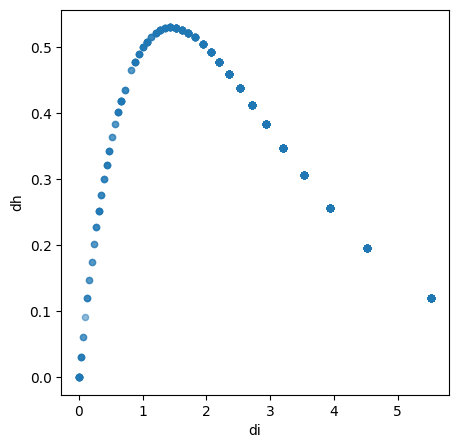

In [221]:
VOCAB.plot.scatter('di', 'dh', figsize=(5,5), alpha=0.5);

In [222]:
VOCAB[VOCAB.dh > .45].sample(10)

,n,p,i,h,n_chars,df,dfidf,z,dp,di,dh
term_str,,,,,,,,,,,
llama,20,0.000559,10.805301,0.006038,5,12,23.263193,2.916162,0.260870,1.938599,0.505722
ha,51,0.001425,9.454803,0.013473,2,19,24.237054,3.109482,0.413043,1.275634,0.526892
junto,13,0.000363,11.426789,0.004151,5,10,22.016339,2.668650,0.217391,2.201634,0.478616
hunahp,88,0.002459,8.667797,0.021313,6,19,24.237054,3.109482,0.413043,1.275634,0.526892
unos,14,0.000391,11.319874,0.004428,4,11,22.705434,2.805441,0.239130,2.064130,0.493596
suelo,11,0.000307,11.667797,0.003586,5,10,22.016339,2.668650,0.217391,2.201634,0.478616
llamaba,35,0.000978,9.997946,0.009778,7,20,24.032677,3.068911,0.434783,1.201634,0.522450
sido,15,0.000419,11.220338,0.004703,4,14,24.026898,3.067764,0.304348,1.716207,0.522324
o,19,0.000531,10.879301,0.005776,1,15,24.250070,3.112066,0.326087,1.616671,0.527175


In [223]:
VOCAB.sort_values('dh', ascending=False).head(20)

,n,p,i,h,n_chars,df,dfidf,z,dp,di,dh
term_str,,,,,,,,,,,
hacer,28,0.000782,10.319874,0.008074,5,17,24.413685,3.144545,0.369565,1.436099,0.530732
muchachos,96,0.002682,8.542266,0.022914,9,17,24.413685,3.144545,0.369565,1.436099,0.530732
tiempo,21,0.000587,10.734911,0.006299,6,17,24.413685,3.144545,0.369565,1.436099,0.530732
nuevo,23,0.000643,10.603667,0.006815,5,17,24.413685,3.144545,0.369565,1.436099,0.530732
vinieron,31,0.000866,10.173032,0.008812,8,17,24.413685,3.144545,0.369565,1.436099,0.530732
vuestra,41,0.001146,9.769677,0.011192,7,17,24.413685,3.144545,0.369565,1.436099,0.530732
yo,38,0.001062,9.879301,0.010490,2,17,24.413685,3.144545,0.369565,1.436099,0.530732
eso,25,0.000699,10.483372,0.007323,3,17,24.413685,3.144545,0.369565,1.436099,0.530732
dios,57,0.001593,9.294339,0.014803,4,17,24.413685,3.144545,0.369565,1.436099,0.530732


In [224]:
VOCAB['stop'] = False
VOCAB.loc[VOCAB.dh <= 0.12, 'stop'] = True

In [225]:
VOCAB[VOCAB.stop == True].index

Index(['a', 'al', 'as', 'con', 'cuando', 'de', 'del', 'el', 'en', 'la', 'las',
       'lo', 'los', 'no', 'por', 'que', 'se', 'su', 'sus', 'una', 'y'],
      dtype='str', name='term_str')

# Visualize Embeddings

In [226]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [228]:
perplexity=10
n_iter=300
# tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity, n_iter=n_iter, init='pca', learning_rate='auto')
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity, init='pca', learning_rate='auto')
reduced_embeddings = tsne.fit_transform(VOCAB_VEC.values)

In [229]:
NONSTOPS = VOCAB.loc[VOCAB.stop == False].index.to_list()

In [230]:
DF = pd.DataFrame(reduced_embeddings, columns=['x', 'y'], index=VOCAB_VEC.index).join(VOCAB)

In [231]:
DF

,x,y,n,p,i,h,n_chars,df,dfidf,z,dp,di,dh,stop
term_str,,,,,,,,,,,,,,
declarar,39.385269,5.039793,2.0,0.000056,14.127229,0.000789,8.0,2.0,9.047124,0.094144,0.043478,4.523562,0.196677,False
diferentes,-74.733269,9.276732,4.0,0.000112,13.127229,0.001467,10.0,4.0,14.094248,1.096044,0.086957,3.523562,0.306397,False
violentamente,-24.830446,29.273281,3.0,0.000084,13.542266,0.001135,13.0,3.0,11.815798,0.643751,0.065217,3.938599,0.256865,False
corteza,-21.036369,-44.070263,1.0,0.000028,15.127229,0.000423,7.0,1.0,5.523562,-0.605315,0.021739,5.523562,0.120077,False
tortuga,-41.938435,-20.715429,4.0,0.000112,13.127229,0.001467,7.0,2.0,9.047124,0.094144,0.043478,4.523562,0.196677,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hacia,50.750294,-1.860496,14.0,0.000391,11.319874,0.004428,5.0,10.0,22.016339,2.668650,0.217391,2.201634,0.478616,False
despido,0.548812,5.705296,1.0,0.000028,15.127229,0.000423,7.0,1.0,5.523562,-0.605315,0.021739,5.523562,0.120077,False
mando,4.936911,-59.256298,1.0,0.000028,15.127229,0.000423,5.0,1.0,5.523562,-0.605315,0.021739,5.523562,0.120077,False


In [232]:
fig = px.scatter(DF.reset_index().sort_values('dh', ascending=False).head(1000), 
           'x', 'y', 
           color='dfidf',
           size='df',
           text='term_str', 
           height=1000)
fig.update_traces(textposition='top center')
fig.show()

# Create DTM

In [233]:
DTM = TOKEN[TOKEN.token_pos.isin(['NOUN','PROPN','VERB']) & (TOKEN.term_str != '')].groupby(OHCO[:2]+['term_str']).term_str.count().unstack(fill_value=0)
STOP = VOCABX[VOCABX.stop == True].index
DTM = DTM[list(set(DTM.columns) - set(STOP))]

In [234]:
# DTM

# Create TFIDF

In [235]:
from sklearn.preprocessing import normalize

In [236]:
TFIDF = DTM * np.log2(len(DTM)/VOCAB.loc[DTM.columns].df)
TFIDF = pd.DataFrame(normalize(TFIDF, norm='l2', axis=1), index=TFIDF.index, columns=TFIDF.columns)
VOCAB['tfidf_mean'] = TFIDF.mean()

# Save

In [237]:
tables = [
    (CHAP, 'CHAP'),
    (TOKEN, 'TOKEN'),
    (VOCAB, 'VOCAB'),
    (VOCABX, 'VOCABX'),
    (BOW, 'BOW'),
    (VOCAB_VEC, 'VOCAB_VEC'),
    (DTM, 'DTM'),
    (TFIDF, 'TFIDF'),
    (DOC, 'DOC'),
    (DOCMAP, 'DOCMAP')
]

In [254]:
for df, df_name in tables:
    df.to_csv(f"recinos-{df_name}.csv", index=True)
    df.to_pickle(f"recinos-{df_name}.pickle")

In [255]:
SPACY.to_pickle('spacy.pickle')

In [256]:
with open(f"recinos-DOC_idx.txt", "w") as out:
    out.write(",".join(DOCMAP.columns))

# Groups for SPAN 4665

In [257]:
runtot = 0
group = 1
data = []
unit_max = 1350 #CHAP.n_words.sum() / 20
for idx, row in CHAP.iterrows():
    runtot += row.n_words
    data.append((idx[0], idx[1], group))
    if runtot > unit_max:
        group += 1
        runtot = 0

In [258]:
CHAP['edit_group'] = pd.DataFrame(data, columns=OHCO + ['edit_group']).set_index(OHCO)

In [259]:
GROUP = CHAP.groupby('edit_group').n_words.sum().to_frame('word_count')

In [260]:
CHAP.edit_group.unstack(fill_value='')

/var/folders/fb/hhf80dqn5x190kxk7_y8557r0000gq/T/ipykernel_53032/3511575154.py:1: Pandas4Warning: Using a fill_value that cannot be held in the existing dtype is deprecated and will raise in a future version.
  CHAP.edit_group.unstack(fill_value='')


capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14
parte,,,,,,,,,,,,,,
0,1,,,,,,,,,,,,,
1,1,1,2,2,2,2,3,3,4,,,,,
2,4,5,6,6,7,8,9,9,10,10,11,11,11,12
3,12,12,13,13,13,14,14,14,15,15,,,,
4,16,16,17,17,17,18,18,19,19,19,20,20,,


In [261]:
CHAP['edit_unit'] = CHAP.index.values

In [262]:
GROUP['chaps'] = CHAP.groupby('edit_group').edit_unit.apply(lambda x: ' '.join(map(str,x)))

In [263]:
GROUP['text_frac'] = np.round(GROUP.word_count / GROUP.word_count.sum(), 3)

In [264]:
GROUP['z'] = (GROUP.word_count - GROUP.word_count.mean()) / GROUP.word_count.std()

<Axes: ylabel='edit_group'>

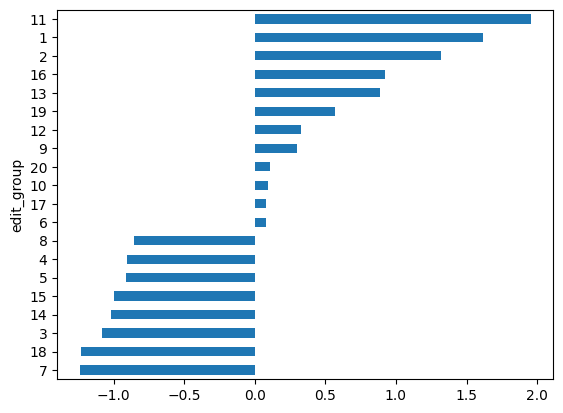

In [265]:
GROUP.z.sort_values().plot.barh()

In [266]:
GROUP

,word_count,chaps,text_frac,z
edit_group,,,,
1,2280,"(0, 1) (1, 1) (1, 2)",0.064,1.615039
2,2190,"(1, 3) (1, 4) (1, 5) (1, 6)",0.061,1.318641
3,1460,"(1, 7) (1, 8)",0.041,-1.085475
4,1515,"(1, 9) (2, 1)",0.042,-0.904343
5,1512,"(2, 2)",0.042,-0.914223
6,1813,"(2, 3) (2, 4)",0.051,0.077063
7,1413,"(2, 5)",0.039,-1.240260
8,1530,"(2, 6)",0.043,-0.854943
9,1880,"(2, 7) (2, 8)",0.053,0.297715


In [267]:
groups = """
Group 1	Walter, Tommy, Parker, Erin
Group 2	Ella, Moira, Filadelfia, Audrey
Group 3	Angie, Nick, Madeline
Group 4	Jack, Alex, Robert
Group 5	Ivy, Luke, Brenna
Group 6	Grayson, Charlotte, Melanie
""".split("\n")[1:-1]

In [268]:
G = pd.DataFrame([g.replace("\t", ", ").split(", ") for g in groups]).set_index(0).stack().to_frame('student').reset_index()

In [270]:
# G.index = pd.Index(range(1,21))

In [271]:
G.columns = ['group', 'member_num', 'student']

In [272]:
G

,group,member_num,student
0,Group 1,1,Walter
1,Group 1,2,Tommy
2,Group 1,3,Parker
3,Group 1,4,Erin
4,Group 2,1,Ella
5,Group 2,2,Moira
6,Group 2,3,Filadelfia
7,Group 2,4,Audrey
8,Group 3,1,Angie
9,Group 3,2,Nick


In [273]:
GROUP = GROUP.join(G)

In [274]:
GROUP.to_html("recinos-groups.html")

In [275]:
GROUP[['word_count','chaps', 'group', 'student']] 

,word_count,chaps,group,student
edit_group,,,,
1,2280,"(0, 1) (1, 1) (1, 2)",Group 1,Tommy
2,2190,"(1, 3) (1, 4) (1, 5) (1, 6)",Group 1,Parker
3,1460,"(1, 7) (1, 8)",Group 1,Erin
4,1515,"(1, 9) (2, 1)",Group 2,Ella
5,1512,"(2, 2)",Group 2,Moira
6,1813,"(2, 3) (2, 4)",Group 2,Filadelfia
7,1413,"(2, 5)",Group 2,Audrey
8,1530,"(2, 6)",Group 3,Angie
9,1880,"(2, 7) (2, 8)",Group 3,Nick


In [276]:
index = {parte:capit for parte, capit in CHAP.index}

In [277]:
for parte in index:
    print(f"-Parte {parte}")
    for capit in range(index[parte]):
        print(f"--{capit+1}")

-Parte 0
--1
-Parte 1
--1
--2
--3
--4
--5
--6
--7
--8
--9
-Parte 2
--1
--2
--3
--4
--5
--6
--7
--8
--9
--10
--11
--12
--13
--14
-Parte 3
--1
--2
--3
--4
--5
--6
--7
--8
--9
--10
-Parte 4
--1
--2
--3
--4
--5
--6
--7
--8
--9
--10
--11
--12
